In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
def fit_func(x,t0,alpha):
    return 0.12*(1+(x/t0)**(2*alpha))**(-0.5)

In [9]:
ramp_times_old = [4.,16.,64.,128.]
ramp_times_old = np.array(ramp_times_old)*1e-3/2.
defect_densities_old = [0.061,0.044,0.031,0.017]
defect_densities_old = np.array(defect_densities_old)

In [10]:
ramp_times = [1.,2.,8.,32.]
ramp_times = np.array(ramp_times)*1e-3/2.
defect_densities = [0.125,0.126,0.062,0.0375]
defect_densities = np.array(defect_densities)

In [23]:
p0_old = [0.06, 0.1, 0.3]
fit_old = curve_fit(fit_func, ramp_times_old, defect_densities_old, p0=p0_old)
print("Old fit parameters:", fit_old[0])

Old fit parameters: [0.0700867  0.00584229 0.50740034]


/tmp/ipykernel_242242/4156057477.py:2: RuntimeWarning: invalid value encountered in power
  return Nsat*(1+(x/t0)**(2*alpha))**(-0.5)


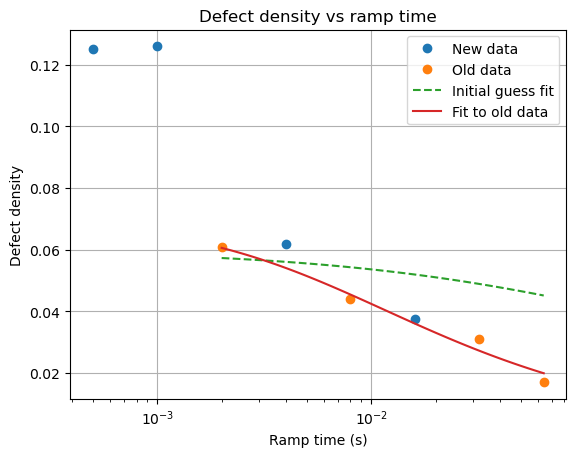

In [22]:
plt.plot(ramp_times, defect_densities, 'o', label='New data')
plt.plot(ramp_times_old, defect_densities_old, 'o', label='Old data')
# plot initial guess fit
x_fit = np.logspace(np.log10(min(ramp_times_old)), np.log10(max(ramp_times_old)), 100)
y_fit = fit_func(x_fit, *p0_old)
plt.plot(x_fit, y_fit, '--', label='Initial guess fit')
plt.plot(x_fit, fit_func(x_fit, *fit_old[0]), '-', label='Fit to old data')
plt.xscale('log')
plt.xlabel('Ramp time (s)')
plt.ylabel('Defect density')
plt.title('Defect density vs ramp time')
plt.legend()
plt.grid(True)
plt.show()